<a href="https://colab.research.google.com/github/Kpellehboy/AI-Commerce-Assistant-API/blob/main/Conference_paper_Plant_detection_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EXPERIMENT SETUP: PlantVillage Curated Subset & Preprocessing Pipeline

In [ ]:
# 1. Install required packages and set Kaggle Credentials
!pip install -q kaggle opencv-python matplotlib tqdm

import os
import shutil
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from glob import glob


# Set the environment variable using the token
os.environ['KAGGLE_API_TOKEN'] = "KGAT_683f7f9073937d2b2adac4d164eabccc"

# PHASE 1: Data Acquisition

In [ ]:
print("Downloading PlantVillage Dataset...")
# We use a widely cited, clean version of the PlantVillage dataset on Kaggle
!kaggle datasets download -d emmarex/plantdisease --unzip

# Define paths (The 'emmarex/plantdisease' dataset extracts to 'PlantVillage')
SOURCE_DIR = 'PlantVillage'
EXPERIMENT_DIR = 'Experiment_Data'

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:41<00:00, 16.7MB/s]



In [ ]:
dataset_path = "PlantVillage"

classes = os.listdir(dataset_path)

print(f"Total Classes: {len(classes)}\n")
for cls in classes:
    print(cls)

Total Classes: 15

Potato___healthy
Tomato_Late_blight
Tomato__Tomato_mosaic_virus
Potato___Late_blight
Tomato_Early_blight
Tomato_Spider_mites_Two_spotted_spider_mite
Potato___Early_blight
Pepper__bell___healthy
Tomato__Tomato_YellowLeaf__Curl_Virus
Tomato_healthy
Pepper__bell___Bacterial_spot
Tomato_Leaf_Mold
Tomato_Bacterial_spot
Tomato_Septoria_leaf_spot
Tomato__Target_Spot


**Select the Classes **

In [ ]:
target_classes = sorted([
    cls for cls in os.listdir("PlantVillage")
    if cls.startswith(("Potato", "Tomato"))
])

print("\n".join(target_classes))

Potato___Early_blight
Potato___Late_blight
Potato___healthy
Tomato_Bacterial_spot
Tomato_Early_blight
Tomato_Late_blight
Tomato_Leaf_Mold
Tomato_Septoria_leaf_spot
Tomato_Spider_mites_Two_spotted_spider_mite
Tomato__Target_Spot
Tomato__Tomato_YellowLeaf__Curl_Virus
Tomato__Tomato_mosaic_virus
Tomato_healthy


**Balancing the 13 Classes**

In [ ]:
# --- Configuration ---
SOURCE_DIR = "PlantVillage"
EXPERIMENT_DIR = "Experiment_Data"
IMAGES_PER_CLASS = 400

# --- Step 1: Select Target Classes ---
target_classes = sorted([
    cls for cls in os.listdir(SOURCE_DIR)
    if cls.startswith(("Potato", "Tomato"))
])

print(f"Total Selected Classes: {len(target_classes)}\n")

# --- Step 2: Reset Output Directory ---
if os.path.exists(EXPERIMENT_DIR):
    shutil.rmtree(EXPERIMENT_DIR)

os.makedirs(EXPERIMENT_DIR, exist_ok=True)

# --- Step 3: Balance Dataset ---
for cls in target_classes:
    src_path = os.path.join(SOURCE_DIR, cls)
    dst_path = os.path.join(EXPERIMENT_DIR, cls)

    os.makedirs(dst_path, exist_ok=True)

    # Get only image files
    images = [
        img for img in os.listdir(src_path)
        if img.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    # --- Balancing Logic ---
    if len(images) >= IMAGES_PER_CLASS:
        selected_images = random.sample(images, IMAGES_PER_CLASS)
    else:
        selected_images = random.choices(images, k=IMAGES_PER_CLASS)

    # --- Copy Images (FIXED INDENTATION) ---
    for i, img in enumerate(selected_images):
        src_file = os.path.join(src_path, img)

        # Unique filename to avoid overwrite
        name, ext = os.path.splitext(img)
        new_name = f"{name}_{i}{ext}"

        dst_file = os.path.join(dst_path, new_name)

        shutil.copy(src_file, dst_file)

    print(f"✔ {cls}: {len(selected_images)} images")

print("\n Balanced dataset ready!")

Total Selected Classes: 13

✔ Potato___Early_blight: 400 images
✔ Potato___Late_blight: 400 images
✔ Potato___healthy: 400 images
✔ Tomato_Bacterial_spot: 400 images
✔ Tomato_Early_blight: 400 images
✔ Tomato_Late_blight: 400 images
✔ Tomato_Leaf_Mold: 400 images
✔ Tomato_Septoria_leaf_spot: 400 images
✔ Tomato_Spider_mites_Two_spotted_spider_mite: 400 images
✔ Tomato__Target_Spot: 400 images
✔ Tomato__Tomato_YellowLeaf__Curl_Virus: 400 images
✔ Tomato__Tomato_mosaic_virus: 400 images
✔ Tomato_healthy: 400 images

 Balanced dataset ready!


**Class Distribution Visualization**

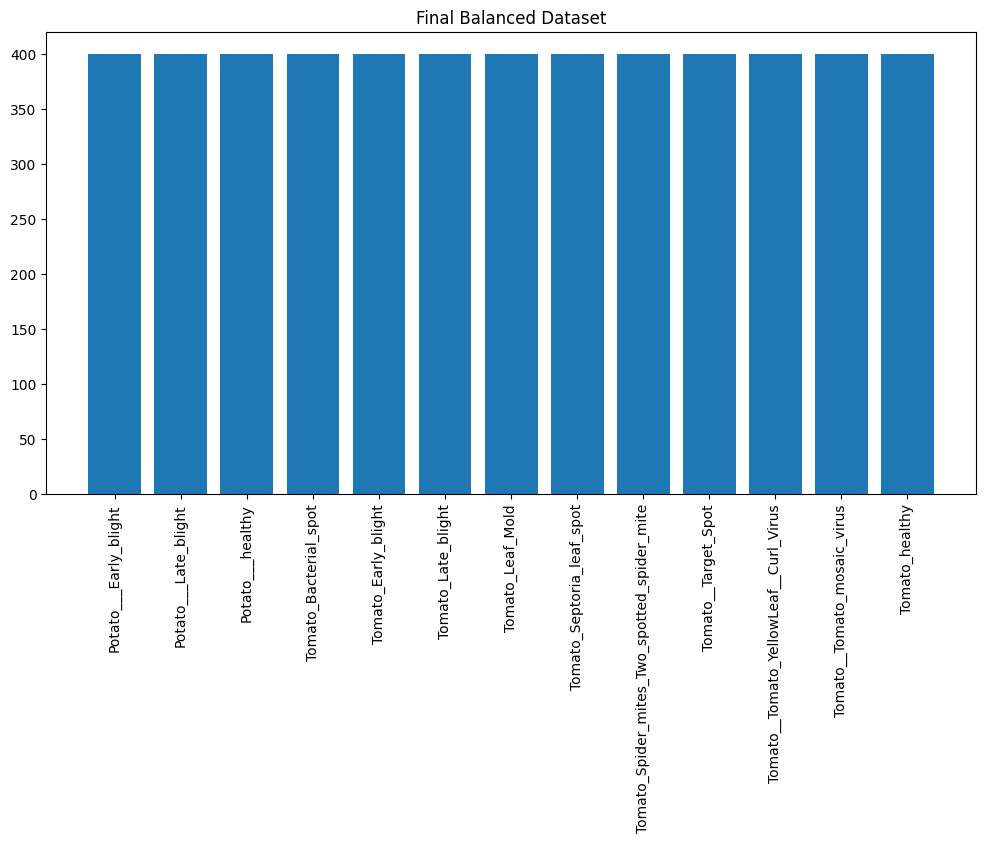

In [ ]:
import matplotlib.pyplot as plt

DATASET_DIR = "Experiment_Data"

classes = sorted(os.listdir(DATASET_DIR))
counts = [len(os.listdir(os.path.join(DATASET_DIR, cls))) for cls in classes]

plt.figure(figsize=(12,6))
plt.bar(classes, counts)
plt.xticks(rotation=90)
plt.title("Final Balanced Dataset")
plt.show()

**Data Splitting**

1. *Training Set (80%): What the model uses to learn.*

2.* Validation Set (10%): The "practice exam" used to tune hyperparameters during training.*

3. *Test Set (10%): The "final exam" that the model only sees once at the very end to prove it actually works.*

In [ ]:
SOURCE_DIR = "Experiment_Data"
OUTPUT_DIR = "Split_Data"

TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1

# Reset output folder
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)

# Create folder structure
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(OUTPUT_DIR, split), exist_ok=True)

classes = sorted(os.listdir(SOURCE_DIR))

for cls in classes:
    class_path = os.path.join(SOURCE_DIR, cls)
    images = os.listdir(class_path)

    random.shuffle(images)

    total = len(images)
    train_end = int(total * TRAIN_RATIO)
    val_end = train_end + int(total * VAL_RATIO)

    train_imgs = images[:train_end]
    val_imgs = images[train_end:val_end]
    test_imgs = images[val_end:]

    # Create class folders inside splits
    for split in ["train", "val", "test"]:
        os.makedirs(os.path.join(OUTPUT_DIR, split, cls), exist_ok=True)

    # Copy files
    def copy_files(file_list, split_name):
        for img in file_list:
            shutil.copy(
                os.path.join(class_path, img),
                os.path.join(OUTPUT_DIR, split_name, cls, img)
            )

    copy_files(train_imgs, "train")
    copy_files(val_imgs, "val")
    copy_files(test_imgs, "test")

    print(f"✔ {cls} → Train:{len(train_imgs)} | Val:{len(val_imgs)} | Test:{len(test_imgs)}")

print("\n Dataset successfully split!")

✔ Potato___Early_blight → Train:320 | Val:40 | Test:40
✔ Potato___Late_blight → Train:320 | Val:40 | Test:40
✔ Potato___healthy → Train:320 | Val:40 | Test:40
✔ Tomato_Bacterial_spot → Train:320 | Val:40 | Test:40
✔ Tomato_Early_blight → Train:320 | Val:40 | Test:40
✔ Tomato_Late_blight → Train:320 | Val:40 | Test:40
✔ Tomato_Leaf_Mold → Train:320 | Val:40 | Test:40
✔ Tomato_Septoria_leaf_spot → Train:320 | Val:40 | Test:40
✔ Tomato_Spider_mites_Two_spotted_spider_mite → Train:320 | Val:40 | Test:40
✔ Tomato__Target_Spot → Train:320 | Val:40 | Test:40
✔ Tomato__Tomato_YellowLeaf__Curl_Virus → Train:320 | Val:40 | Test:40
✔ Tomato__Tomato_mosaic_virus → Train:320 | Val:40 | Test:40
✔ Tomato_healthy → Train:320 | Val:40 | Test:40

 Dataset successfully split!


**Verification**

In [ ]:
for split in ["train", "val", "test"]:
    print(f"\n{split.upper()}")
    for cls in classes:
        count = len(os.listdir(os.path.join("Split_Data", split, cls)))
        print(cls, ":", count)


TRAIN
Potato___Early_blight : 320
Potato___Late_blight : 320
Potato___healthy : 320
Tomato_Bacterial_spot : 320
Tomato_Early_blight : 320
Tomato_Late_blight : 320
Tomato_Leaf_Mold : 320
Tomato_Septoria_leaf_spot : 320
Tomato_Spider_mites_Two_spotted_spider_mite : 320
Tomato__Target_Spot : 320
Tomato__Tomato_YellowLeaf__Curl_Virus : 320
Tomato__Tomato_mosaic_virus : 320
Tomato_healthy : 320

VAL
Potato___Early_blight : 40
Potato___Late_blight : 40
Potato___healthy : 40
Tomato_Bacterial_spot : 40
Tomato_Early_blight : 40
Tomato_Late_blight : 40
Tomato_Leaf_Mold : 40
Tomato_Septoria_leaf_spot : 40
Tomato_Spider_mites_Two_spotted_spider_mite : 40
Tomato__Target_Spot : 40
Tomato__Tomato_YellowLeaf__Curl_Virus : 40
Tomato__Tomato_mosaic_virus : 40
Tomato_healthy : 40

TEST
Potato___Early_blight : 40
Potato___Late_blight : 40
Potato___healthy : 40
Tomato_Bacterial_spot : 40
Tomato_Early_blight : 40
Tomato_Late_blight : 40
Tomato_Leaf_Mold : 40
Tomato_Septoria_leaf_spot : 40
Tomato_Spider_mit

**Model Training**

In [ ]:
!pip install tensorflow

import tensorflow as tf
from tensorflow.keras import layers, models

**Step 2: Load Dataset (from the split)**

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "Split_Data/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "Split_Data/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "Split_Data/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 4160 files belonging to 13 classes.
Found 520 files belonging to 13 classes.
Found 520 files belonging to 13 classes.


**Train**

In [ ]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "Split_Data/train",
    image_size=(224, 224),
    batch_size=32
)

# SAVE BEFORE prefetch
class_names = train_ds.class_names
num_classes = len(class_names)

Found 4160 files belonging to 13 classes.


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)

**Step 3: Optimize Performance**

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

**Step 4: Data Augmentation**

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

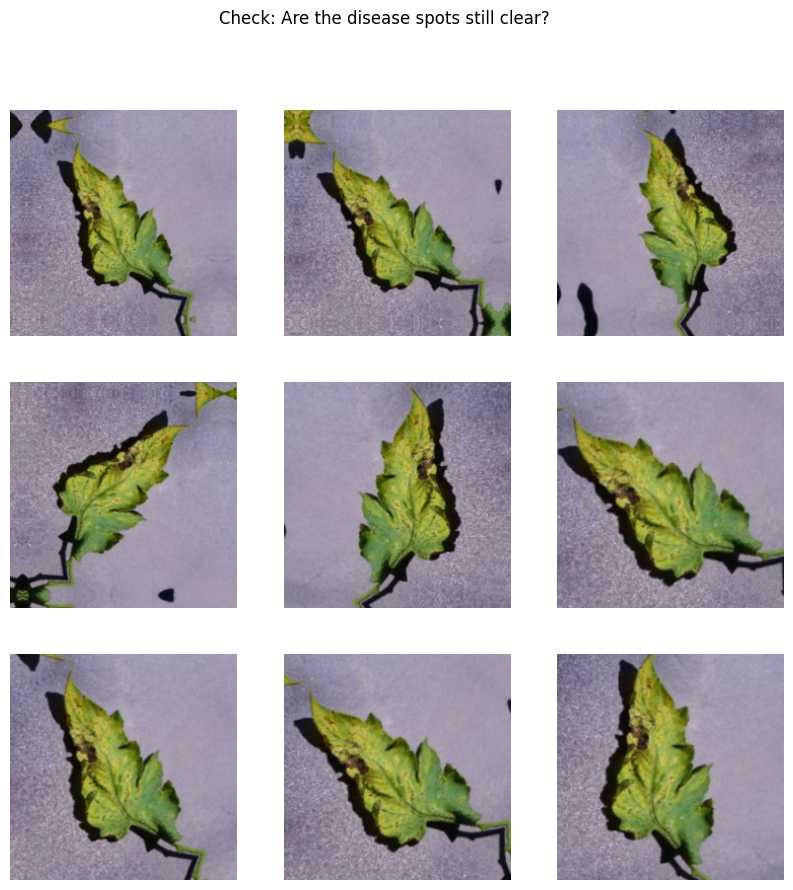

In [ ]:
import matplotlib.pyplot as plt

# Take one image from your training set
for images, _ in train_ds.take(1):
  plt.figure(figsize=(10, 10))
  first_image = images[0]
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    # Apply the augmentation to the same image 9 different times
    augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
    plt.imshow(augmented_image[0].numpy().astype("uint8"))
    plt.axis("off")
  plt.suptitle("Check: Are the disease spots still clear?")
  plt.show()

**Step 5: Load Pretrained Model (MobileNetV2)**

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False  # Freeze base model

**Step 6: Build Model**

In [ ]:
model = models.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

**Step 7: Compile Model**

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

**Step 8: Train Model**

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[checkpoint]
)

Epoch 1/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.4036 - loss: 2.0855
Epoch 1: val_accuracy improved from None to 0.78269, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
130/130 ━━━━━━━━━━━━━━━━━━━━ 16s 72ms/step - accuracy: 0.5611 - loss: 1.4728 - val_accuracy: 0.7827 - val_loss: 0.7669
Epoch 2/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.7099 - loss: 0.9089
Epoch 2: val_accuracy improved from 0.78269 to 0.81538, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
130/130 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - accuracy: 0.7168 - loss: 0.8910 - val_accuracy: 0.8154 - val_loss: 0.5629
Epoch 3/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.7540 - loss: 0.7555
Epoch 3: val_accuracy improved from 0.81538 to 0.82500, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
130/130 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - accuracy: 0.7647 - loss: 0.7368 - val_accuracy: 0.8250 - val_loss: 0.5107
Epoch 4/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.7872 - loss: 0.6365
Epoch 4: val_accuracy did not improve from 0.82500
130/130 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - accuracy: 0.7786 - loss: 0.6503 - val_accuracy: 0.8000 - val_loss: 0.5544
Epoch 5/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8036 - loss: 0.5828
Epoch 5: val_accuracy improved from 0.82500 to 0.84231, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
130/130 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - accuracy: 0.8012 - loss: 0.5973 - val_accuracy: 0.8423 - val_loss: 0.4694
Epoch 6/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.8098 - loss: 0.5634
Epoch 6: val_accuracy did not improve from 0.84231
130/130 ━━━━━━━━━━━━━━━━━━━━ 8s 61ms/step - accuracy: 0.8125 - loss: 0.5476 - val_accuracy: 0.8308 - val_loss: 0.5046
Epoch 7/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8168 - loss: 0.5143
Epoch 7: val_accuracy did not improve from 0.84231
130/130 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - accuracy: 0.8228 - loss: 0.5047 - val_accuracy: 0.8385 - val_loss: 0.4690
Epoch 8/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8375 - loss: 0.4783
Epoch 8: val_accuracy improved from 0.84231 to 0.86346, saving model to best_model.h5



Epoch 8: finished saving model to best_model.h5
130/130 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - accuracy: 0.8267 - loss: 0.5031 - val_accuracy: 0.8635 - val_loss: 0.4506
Epoch 9/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8496 - loss: 0.4552
Epoch 9: val_accuracy did not improve from 0.86346
130/130 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - accuracy: 0.8474 - loss: 0.4573 - val_accuracy: 0.8635 - val_loss: 0.3896
Epoch 10/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8516 - loss: 0.4373
Epoch 10: val_accuracy did not improve from 0.86346
130/130 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - accuracy: 0.8394 - loss: 0.4599 - val_accuracy: 0.8500 - val_loss: 0.4080
Epoch 11/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8402 - loss: 0.4651
Epoch 11: val_accuracy improved from 0.86346 to 0.87885, saving model to best_model.h5



Epoch 11: finished saving model to best_model.h5
130/130 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - accuracy: 0.8474 - loss: 0.4513 - val_accuracy: 0.8788 - val_loss: 0.3724
Epoch 12/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8549 - loss: 0.3966
Epoch 12: val_accuracy did not improve from 0.87885
130/130 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - accuracy: 0.8599 - loss: 0.4093 - val_accuracy: 0.8500 - val_loss: 0.4443
Epoch 13/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8599 - loss: 0.4024
Epoch 13: val_accuracy did not improve from 0.87885
130/130 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - accuracy: 0.8575 - loss: 0.4165 - val_accuracy: 0.8596 - val_loss: 0.3959
Epoch 14/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8627 - loss: 0.4037
Epoch 14: val_accuracy did not improve from 0.87885
130/130 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - accuracy: 0.8536 - loss: 0.4255 - val_accuracy: 0.8519 - val_loss: 0.4263
Epoch 15/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - ac

**Step 9: Evaluate Model**

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nTest Accuracy: {test_acc:.4f}")

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.8577 - loss: 0.4399

Test Accuracy: 0.8577


**Step 10: Plot Accuracy & Loss**

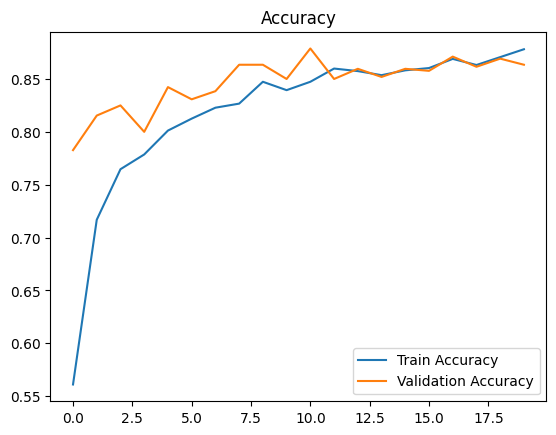

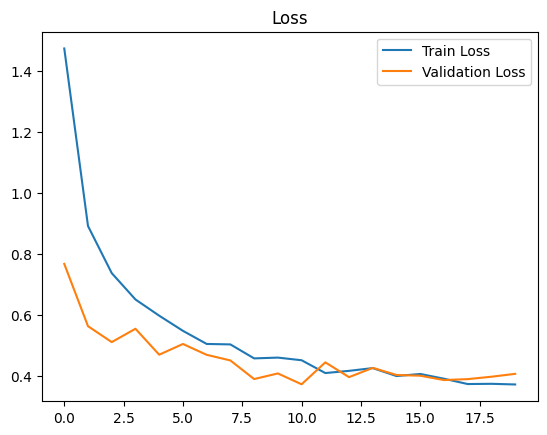

In [ ]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

# Accuracy Plot
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss Plot
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend()
plt.title("Loss")
plt.show()

**Fine-Tuning**

In [ ]:
# 1. Unfreeze the base model
base_model.trainable = True

# 2. FREEZE the bottom layers (e.g., all but the last 20 layers)
# This protects the foundation of the model
for layer in base_model.layers[:-20]:
    layer.trainable = False

# 3. CRITICAL: Force Batch Normalization layers to stay frozen
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# 4. Recompile with your very low learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy', # Keeping your loss function
    metrics=['accuracy']
)

# 5. Resume Training
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 16s 76ms/step - accuracy: 0.8803 - loss: 0.3407 - val_accuracy: 0.8750 - val_loss: 0.3702
Epoch 2/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - accuracy: 0.8870 - loss: 0.3329 - val_accuracy: 0.8558 - val_loss: 0.4491
Epoch 3/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - accuracy: 0.8954 - loss: 0.3150 - val_accuracy: 0.8923 - val_loss: 0.3545
Epoch 4/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - accuracy: 0.9022 - loss: 0.3056 - val_accuracy: 0.8846 - val_loss: 0.3887
Epoch 5/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - accuracy: 0.9036 - loss: 0.2756 - val_accuracy: 0.8808 - val_loss: 0.3764
Epoch 6/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - accuracy: 0.8993 - loss: 0.2851 - val_accuracy: 0.8865 - val_loss: 0.3820
Epoch 7/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - accuracy: 0.9022 - loss: 0.2733 - val_accuracy: 0.8904 - val_loss: 0.3144
Epoch 8/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step - accuracy: 0.9123 - loss: 0.2575 - val_acc

In [ ]:
# Evaluate the fine-tuned model
final_test_loss, final_test_acc = model.evaluate(test_ds)
print(f"Fine-Tuned Test Accuracy: {final_test_acc*100:.2f}%")

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.9038 - loss: 0.3323
Fine-Tuned Test Accuracy: 90.38%


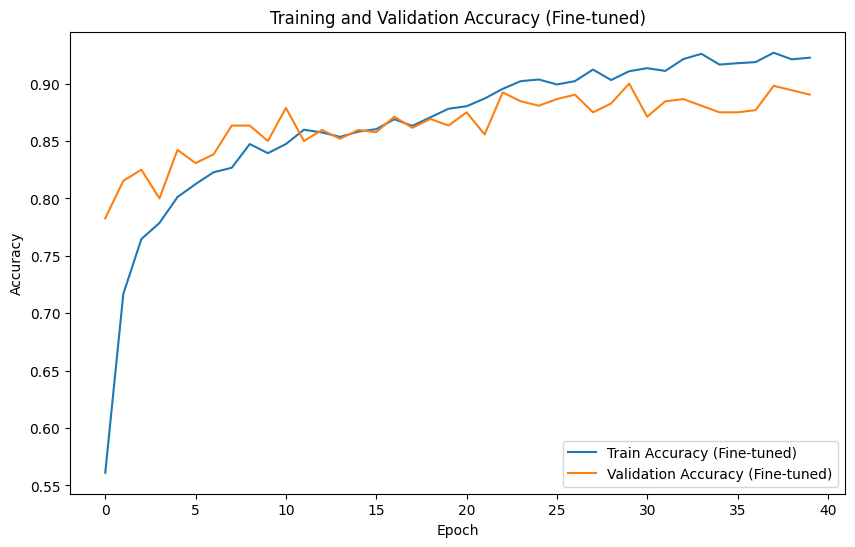

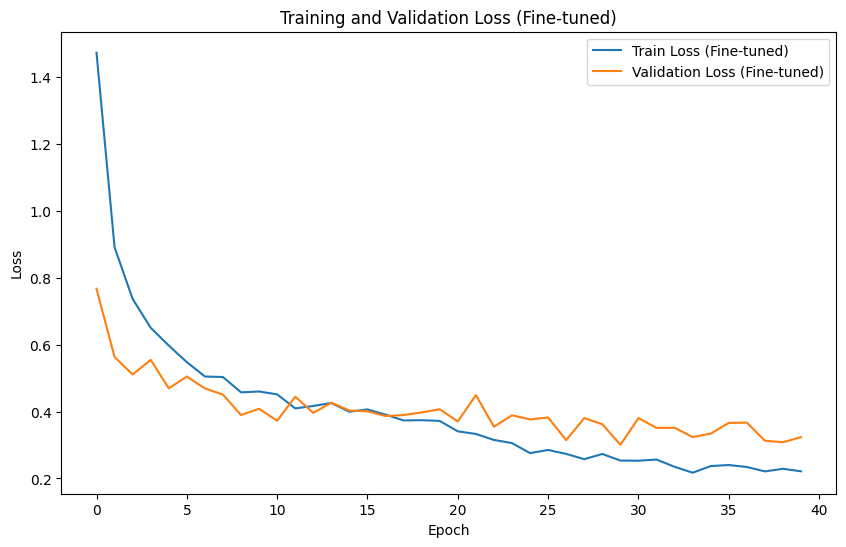

Final Train Accuracy after Fine-Tuning: 0.9226
Final Validation Accuracy after Fine-Tuning: 0.8904


In [ ]:
import matplotlib.pyplot as plt

# Combine histories
total_acc = history.history['accuracy'] + history_fine.history['accuracy']
total_val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']

total_loss = history.history['loss'] + history_fine.history['loss']
total_val_loss = history.history['val_loss'] + history_fine.history['val_loss']

# Accuracy Plot for fine-tuned model
plt.figure(figsize=(10, 6))
plt.plot(total_acc, label='Train Accuracy (Fine-tuned)')
plt.plot(total_val_acc, label='Validation Accuracy (Fine-tuned)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy (Fine-tuned)')
plt.show()

# Loss Plot for fine-tuned model
plt.figure(figsize=(10, 6))
plt.plot(total_loss, label='Train Loss (Fine-tuned)')
plt.plot(total_val_loss, label='Validation Loss (Fine-tuned)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss (Fine-tuned)')
plt.show()

print(f"Final Train Accuracy after Fine-Tuning: {total_acc[-1]:.4f}")
print(f"Final Validation Accuracy after Fine-Tuning: {total_val_acc[-1]:.4f}")

**The Final Diagnostic: Confusion Matrix**

Generating predictions...
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step


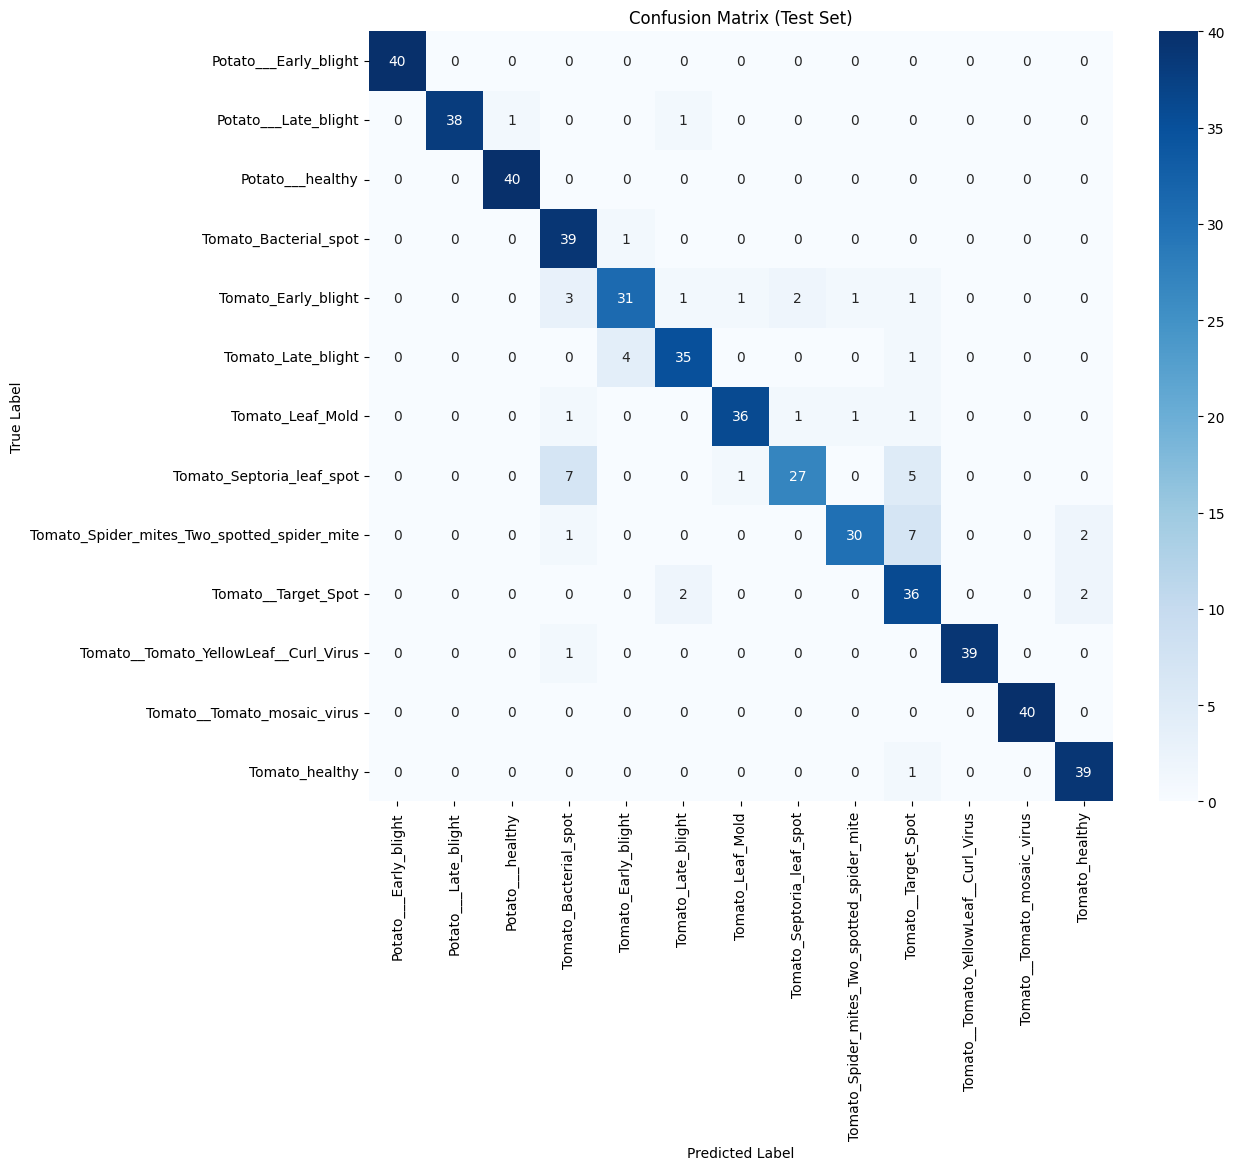

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# class names
# The class_names variable was already correctly extracted and is available in the kernel.
# No need to re-extract from train_ds as it's now a _PrefetchDataset.
# class_names = train_ds.class_names # Removed problematic line

print("Generating predictions...")

y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true = np.concatenate([y for x, y in test_ds], axis=0)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Test Set)')
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.show()

In [ ]:
from sklearn.metrics import classification_report

# The 'classes' variable contains the correct 13 class names from the data splitting step.
print(classification_report(y_true, y_pred, target_names=classes))

                                             precision    recall  f1-score   support

                      Potato___Early_blight       1.00      1.00      1.00        40
                       Potato___Late_blight       1.00      0.95      0.97        40
                           Potato___healthy       0.98      1.00      0.99        40
                      Tomato_Bacterial_spot       0.75      0.97      0.85        40
                        Tomato_Early_blight       0.86      0.78      0.82        40
                         Tomato_Late_blight       0.90      0.88      0.89        40
                           Tomato_Leaf_Mold       0.95      0.90      0.92        40
                  Tomato_Septoria_leaf_spot       0.90      0.68      0.77        40
Tomato_Spider_mites_Two_spotted_spider_mite       0.94      0.75      0.83        40
                        Tomato__Target_Spot       0.69      0.90      0.78        40
      Tomato__Tomato_YellowLeaf__Curl_Virus       1.00      0.97

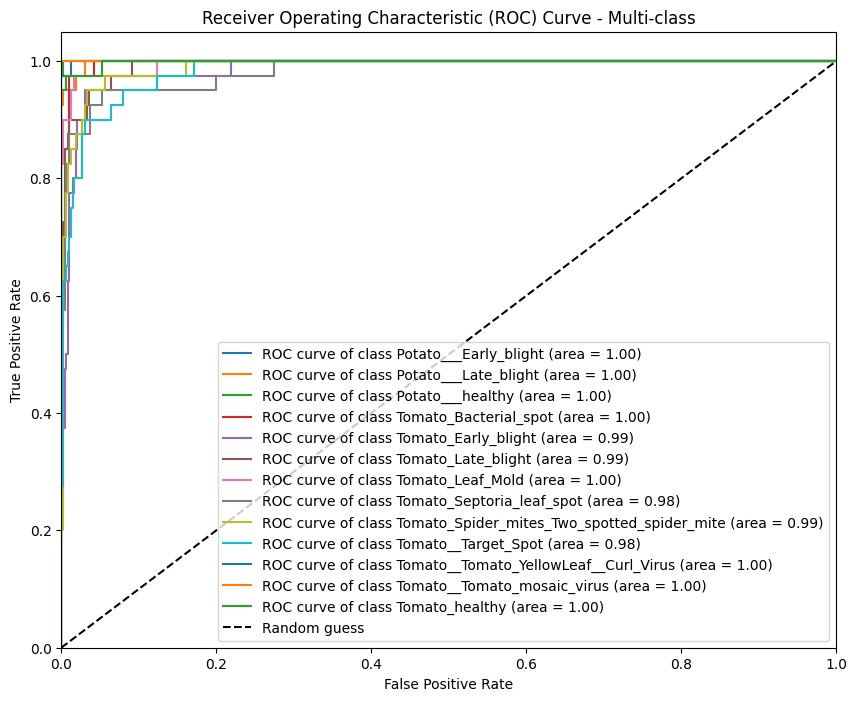

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Get true labels and predicted probabilities for the test set
# y_true is already available from the confusion matrix step
# y_pred_probs is also already available from the confusion matrix step

# Calculate ROC curve and AUC for each class
n_classes = len(class_names)

# Binarize the true labels for ROC calculation
y_true_binarized = tf.keras.utils.to_categorical(y_true, num_classes=n_classes)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'ROC curve of class {class_names[i]} (area = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Multi-class')
plt.legend(loc="lower right")
plt.show()